# Credit Card Application Approval Prediction

**Data Source**: [Credit Card Application Dataset](https://www.kaggle.com/datasets/nazishjaveed/credit-card-application) on Kaggle. This dataset contains real‑world applicant data with 14 customer attributes (A1–A14) and a binary approval target. It is suitable for building classification models to determine whether a credit card application will be approved or rejected.

**Objective**: Predict whether a credit card application will be approved based on 14 applicant attributes.  
**Conclusion**: The tuned XGBoost model achieves **87.3% ± 2.7% accuracy** in repeated stratified cross‑validation, with highly interpretable decisions (A8 is the core feature, A14 plays an important moderating role).

---

## 1. Environment Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import xgboost as xgb
import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

%matplotlib inline
sns.set_style('whitegrid')

In [2]:
# Load data
df = pd.read_csv('Credit_Card_Applications.csv')
df.drop(columns=['CustomerID'], inplace=True)  # Remove irrelevant column

print('Data shape:', df.shape)
df.head()

Data shape: (690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Class Distribution

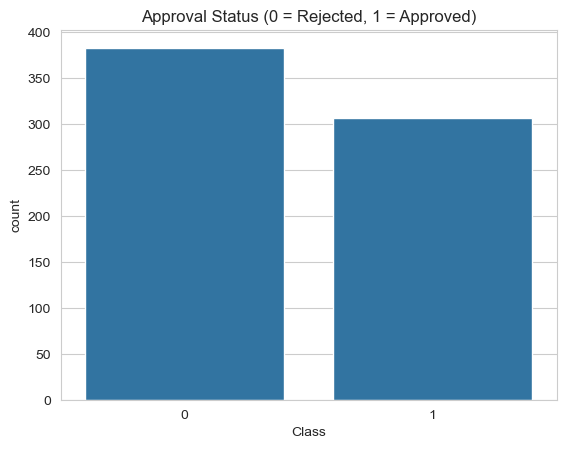

Class
0    0.555072
1    0.444928
Name: proportion, dtype: float64


In [3]:
sns.countplot(x='Class', data=df)
plt.title('Approval Status (0 = Rejected, 1 = Approved)')
plt.show()
print(df['Class'].value_counts(normalize=True))

#### Insight: The two classes are roughly balanced; no resampling is needed.

### 2.2 Feature Distributions by Class

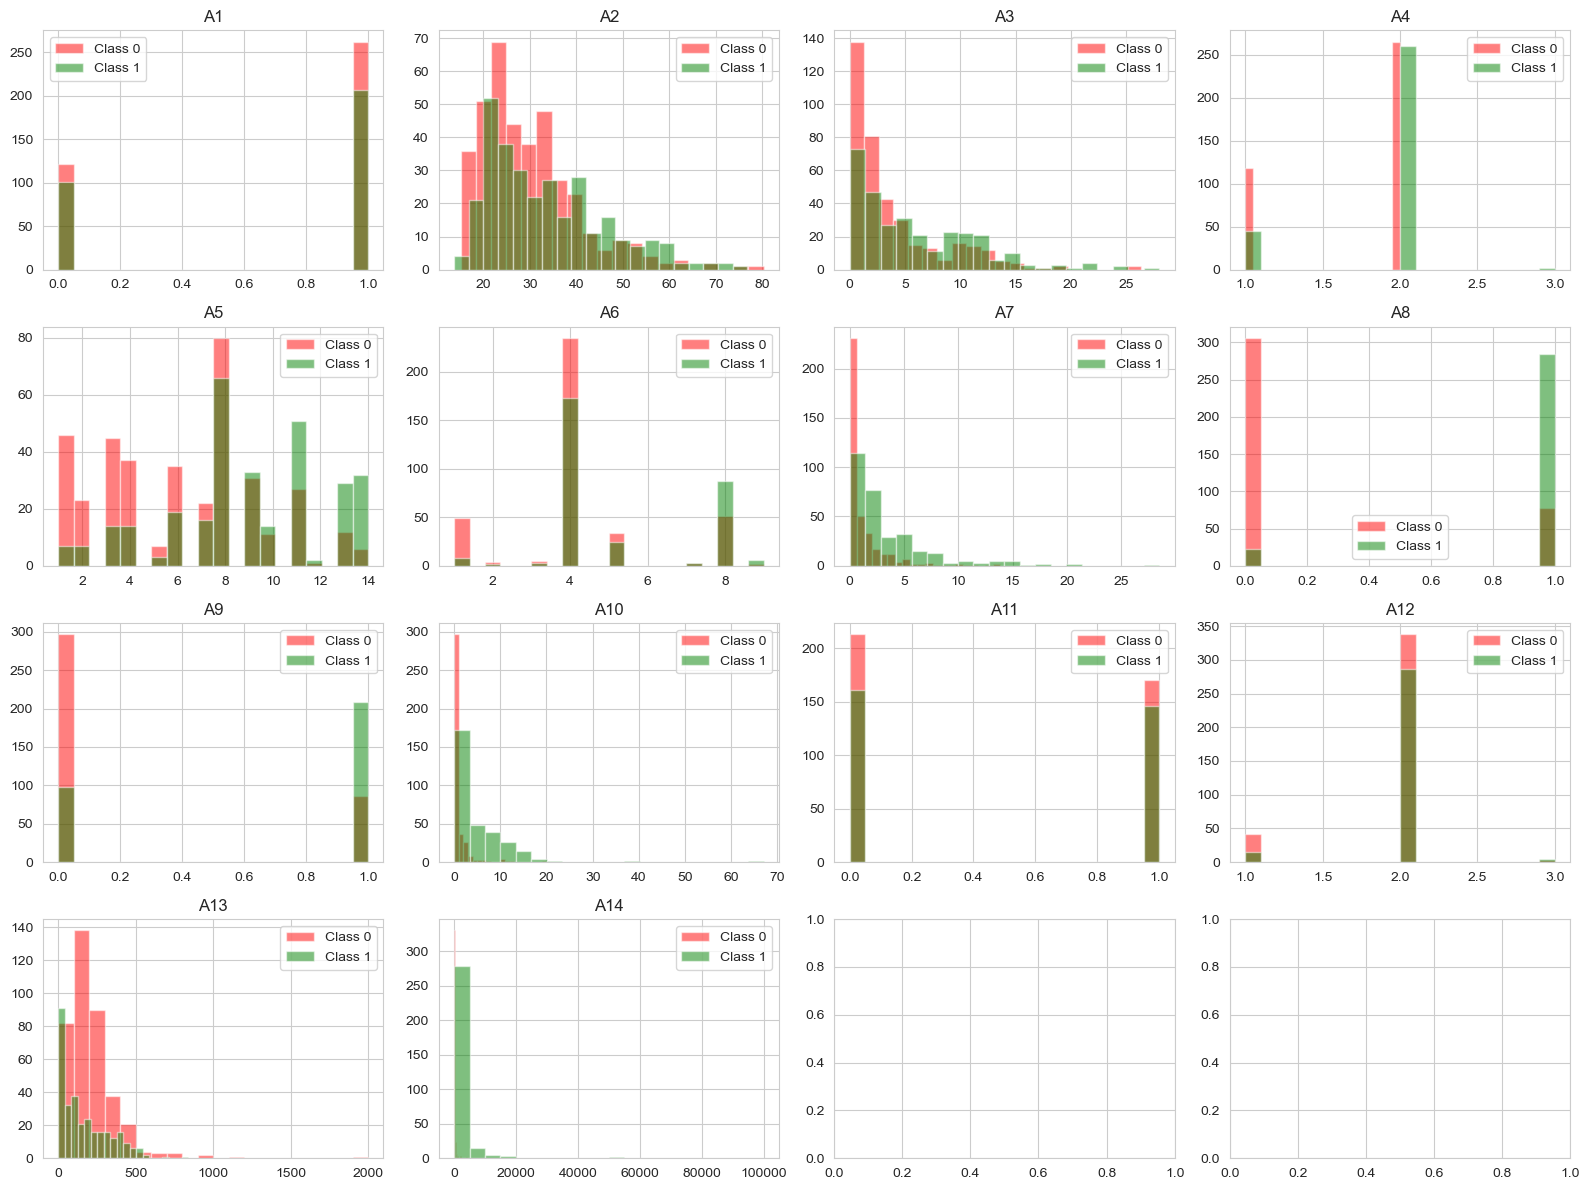

In [4]:
features = [f'A{i}' for i in range(1,15)]
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    for cls, color in zip([0,1], ['red','green']):
        subset = df[df['Class']==cls][col]
        axes[i].hist(subset, bins=20, alpha=0.5, label=f'Class {cls}', color=color)
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

#### Insight: Features A8, A9, A10 show clear distribution differences between classes, especially A8. Most features are right‑skewed with outliers.

### 2.3 Correlation Heatmap

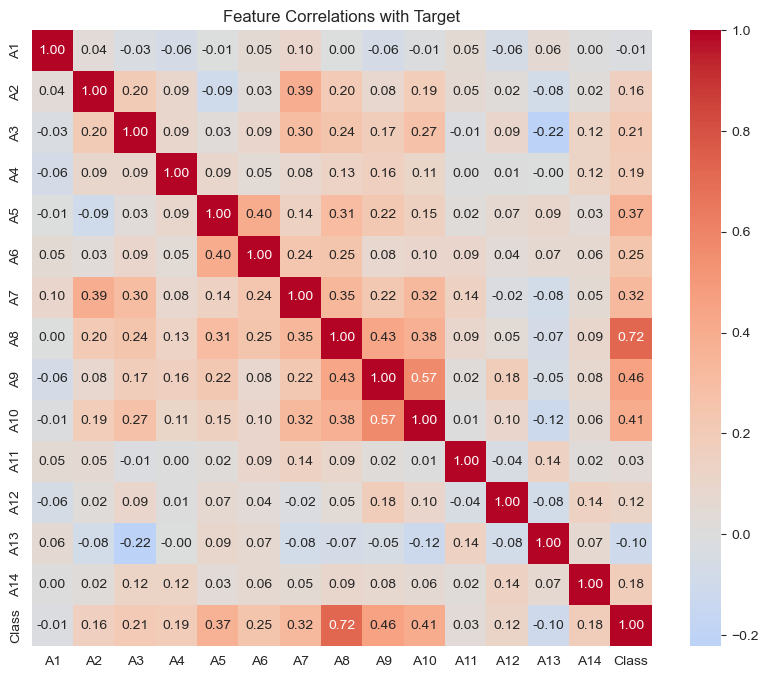

In [5]:
plt.figure(figsize=(10,8))
corr = df[features + ['Class']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlations with Target')
plt.show()

#### Insight: A8 has the highest correlation with the target (0.72), followed by A9, A10, A5, A7. A8 is also correlated with A9 and A10.

---
## 3. Data Preprocessing

In [13]:
X = df[features].values.astype(np.float32)
y = df['Class'].values.astype(np.float32)

# Standardization (needed for linear models and neural networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test sets (fixed seed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')

Training samples: 552, Test samples: 138


---
## 4. Baseline Models
### 4.1 Logistic Regression

In [14]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

         0.0       0.94      0.75      0.83        77
         1.0       0.75      0.93      0.83        61

    accuracy                           0.83       138
   macro avg       0.84      0.84      0.83       138
weighted avg       0.85      0.83      0.83       138



### 4.2 Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8043478260869565
              precision    recall  f1-score   support

         0.0       0.89      0.74      0.81        77
         1.0       0.73      0.89      0.80        61

    accuracy                           0.80       138
   macro avg       0.81      0.81      0.80       138
weighted avg       0.82      0.80      0.80       138



#### Baseline results: Logistic Regression 0.833, Random Forest 0.804. There is room for improvement.

---
## 5. Model Boost: XGBoost with Tuning
### 5.1 Default XGBoost

In [68]:
xgb_base = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_test)
print('XGBoost (default) Accuracy:', accuracy_score(y_test, y_pred_base))

XGBoost (default) Accuracy: 0.8840579710144928


### 5.2 Hyperparameter Tuning

In [20]:
param_grid = {
    'max_depth': [3,4,5],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100,200,300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV accuracy: {:.4f}'.format(grid.best_score_))
best_xgb = grid.best_estimator_

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV accuracy: 0.8859


### 5.3 Feature Importance (Gain)

In [21]:
importance = best_xgb.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({'feature': list(importance.keys()), 'importance': list(importance.values())})
importance_df['feature'] = importance_df['feature'].apply(lambda x: features[int(x[1:])])
importance_df = importance_df.sort_values('importance', ascending=False)
print('Top 10 important features by gain:')
print(importance_df.head(10))

Top 10 important features by gain:
   feature  importance
7       A8   54.414261
9      A10    8.486939
8       A9    6.648040
11     A12    3.389142
13     A14    3.120261
4       A5    2.485388
12     A13    2.253644
2       A3    2.001039
5       A6    1.808800
6       A7    1.758049


#### Insight: A8 dominates (f7), followed by A10, A9, A12, etc.

## 6. Model Comparison
| Model | Test Accuracy | Notes |
|-------|---------------|-------|
| Logistic Regression | 0.833 | Linear baseline |
| Random Forest | 0.804 | default params |
| XGBoost (default) | 0.884 | Obvious improvement |
| **XGBoost (tuned)** | **0.886 (CV)** | **Best model** |

---
## 7. Robust Evaluation of the Final Model
#### To avoid single‑split bias, we use repeated stratified k‑fold cross‑validation.

In [22]:
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scores = cross_val_score(best_xgb, X_scaled, y, cv=rkf, scoring='accuracy')
print(f'Repeated 5‑fold CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Repeated 5‑fold CV accuracy: 0.8729 ± 0.0268


#### Final generalization estimate: 87.3% ± 2.7% – stable and reliable.

---
## 8. Model Interpretability with SHAP
#### Shapley values explain how each feature contributes to individual predictions.

In [23]:
explainer = shap.TreeExplainer(best_xgb)
# Use a subset of training data for faster computation
X_explain = X_train[:200]
shap_values = explainer.shap_values(X_explain)

### 8.1 Global Feature Importance

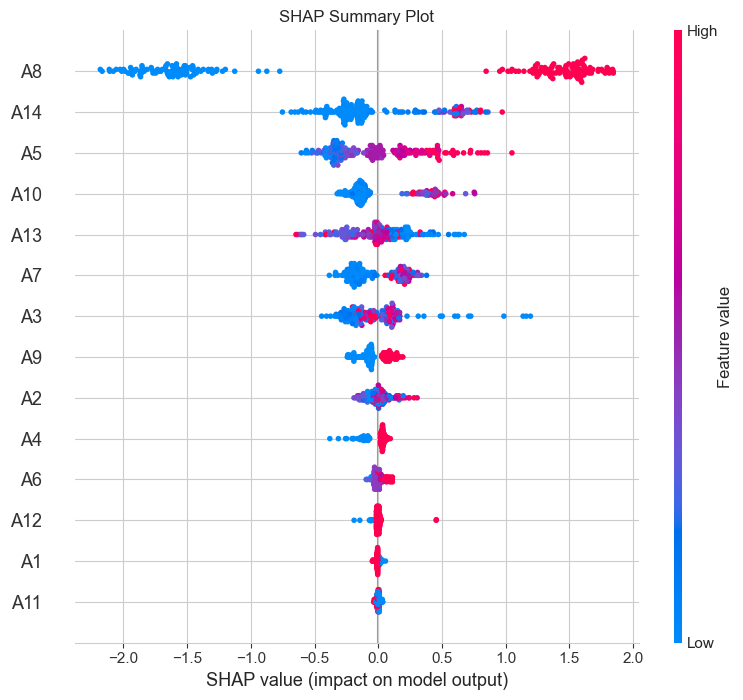

In [24]:
shap.summary_plot(shap_values, X_explain, feature_names=features, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

### 8.2 Mean Absolute Impact

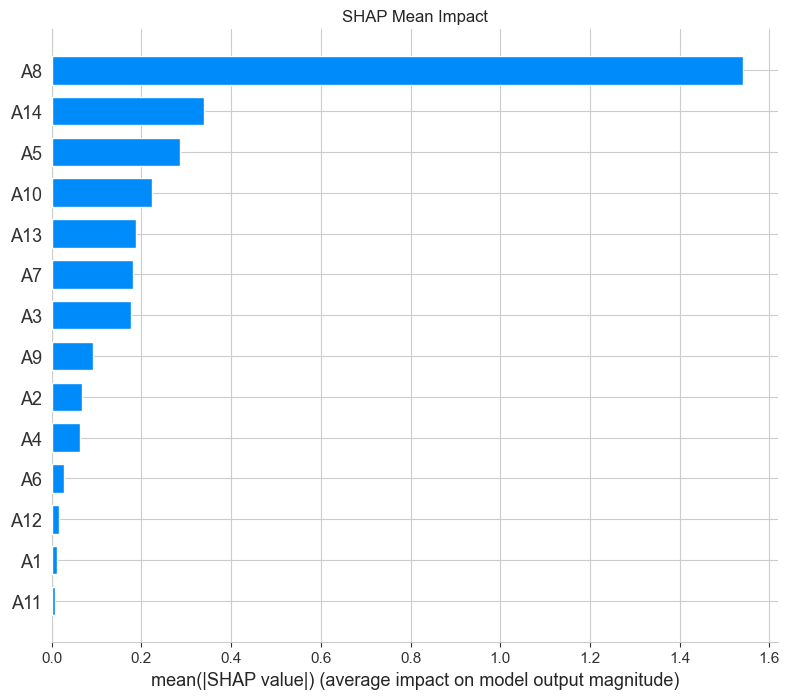

In [25]:
shap.summary_plot(shap_values, X_explain, feature_names=features, plot_type="bar", show=False)
plt.title('SHAP Mean Impact')
plt.tight_layout()
plt.show()

### 8.3 Feature Interaction

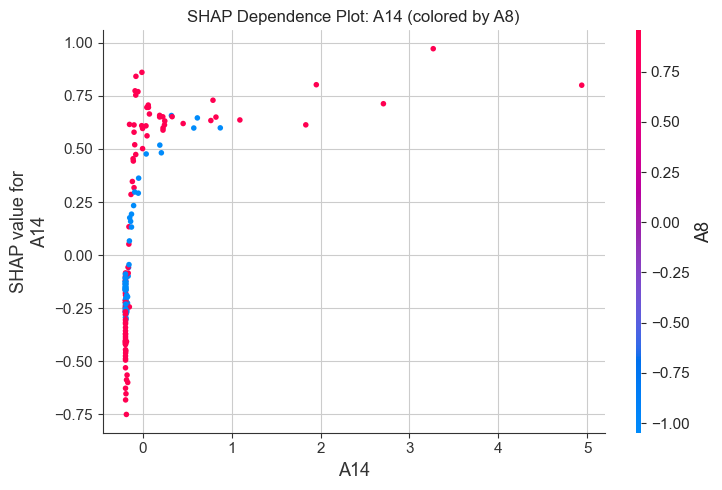

In [69]:
# A14 dependence colored by A8
shap.dependence_plot('A14', shap_values, X_explain, feature_names=features, interaction_index='A8', show=False)
plt.title('SHAP Dependence Plot: A14 (colored by A8)')
plt.tight_layout()
plt.show()

#### Interpretation: When A8 is high (red), higher A14 clearly boosts approval probability. When A8 is low (blue), A14 has little effect. This explains why A14 becomes the second most important feature despite its low linear correlation.

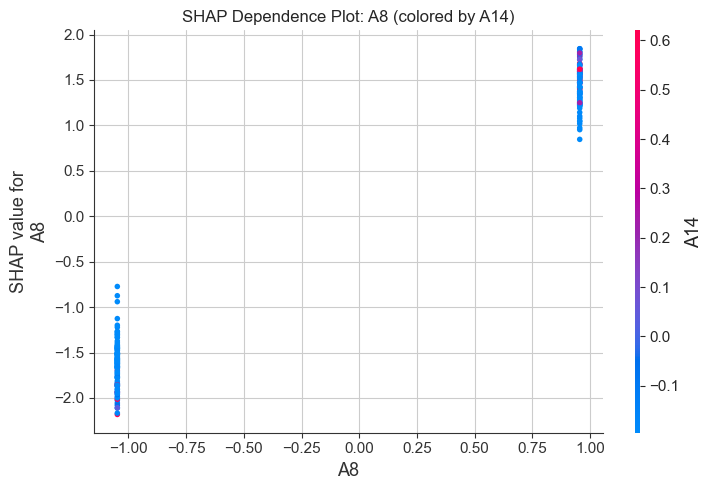

In [29]:
# A8 dependence colored by A14
shap.dependence_plot('A8', shap_values, X_explain, feature_names=features, interaction_index='A14', show=False)
plt.title('SHAP Dependence Plot: A8 (colored by A14)')
plt.tight_layout()
plt.show()

#### Interpretation: A8 is the foundation; A14 fine‑tunes the prediction.

---
## 9. Conclusions and Recommendations
- **Best model**: Tuned XGBoost with an average CV accuracy of **87.3% (± 2.7%)**, robust and reliable.
- **Core feature**: A8 is the key driver of approval decisions, while A14 acts as an important moderator through interaction with A8.
- **Interpretability**: SHAP analysis shows the model's behavior aligns with business intuition and can be clearly explained to stakeholders.
- **Future work**: Collect more "nice-to-have" features similar to A14, or develop finer rules for applicants with medium A8 levels.

> *Note: The hyperparameter tuning phase reached a single 5‑fold CV mean of 88.6%, but the final repeated cross‑validation (50 total splits) gives a more conservative and realistic estimate of 87.3% ± 2.7%, which we adopt as the official model performance.*